# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,) 

In [78]:
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#9467bd', '#c78fe0', '#7b2c9e', '#b66ad0'])

In [79]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns = data.feature_names)
y = pd.Series(data.target, name = "target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index = {0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


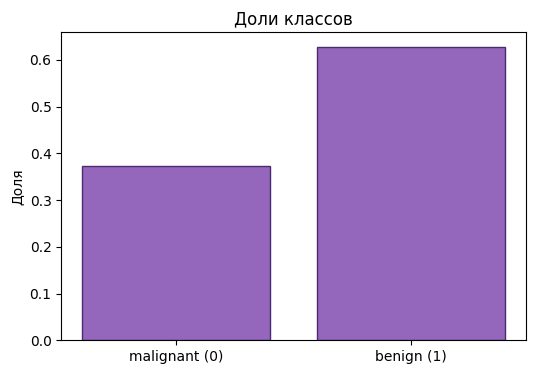

In [80]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending = False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize = True).sort_index()
plt.figure(figsize = (6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values,
        color = '#9467bd', edgecolor = '#4a2c6e')   # фиолетовый с тёмной обводкой
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [81]:
# ШАГ 1: Разделяем данные и стандартизируем признаки

# train_test_split делит данные на обучающую и тестовую части
# test_size=0.2 → 20% в тест, 80% в train
# stratify=y → в каждой части одинаковое соотношение классов
# random_state фиксирует случайность для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

# StandardScaler нормирует признаки: (x - mean) / std
# fit() считает mean и std ТОЛЬКО на train — чтобы не "подглядывать" в тест
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # только transform, не fit!

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [82]:
def sigmoid(z):
    # Сигмоида: превращает любое число в вероятность от 0 до 1
    # Формула: 1 / (1 + e^(-z))
    # При z=0 → 0.5, при z→+∞ → 1, при z→-∞ → 0
    return 1.0 / (1.0 + np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))


sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [83]:
def compute_log_loss(y_true, y_pred_proba):
    # Log-loss (кросс-энтропия) — стандартная функция потерь для классификации
    # Формула: -mean( y*log(p) + (1-y)*log(1-p) )
    # eps нужен чтобы не брать log(0) — это минус бесконечность
    eps = 1e-15
    p = np.clip(y_pred_proba, eps, 1 - eps)  # ограничиваем [eps, 1-eps]
    loss = -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))


Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = 
rac{1}{n} X^T(\hat{p} - y), \qquad db = 
rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [84]:
def forward_backward(X, y, w, b):
    n = X.shape[0]  # количество объектов

    # 1) Линейная комбинация
    z = X @ w + b

    # 2) Применяем сигмоиду, получаем предсказанные вероятности
    p = sigmoid(z)

    # 3) Log-loss
    loss = compute_log_loss(y, p)

    # 4) Градиенты (выводятся из производной log-loss по w и b)
    # dL/dw = (1/n) * X^T @ (p - y)
    # dL/db = (1/n) * sum(p - y)
    error = p - y
    dw = (X.T @ error) / n
    db = error.mean()

    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)


Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [85]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate = 0.05, n_iters = 3000, threshold = 0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # Инициализируем веса нулями
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        self.loss_history = []

        # Градиентный спуск: n_iters шагов
        for _ in range(self.n_iters):
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            # Обновляем параметры в направлении антиградиента
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            self.loss_history.append(loss)
        return self

    def predict_proba(self, X):
        # Считаем вероятности через сигмоиду
        z = X @ self.w + self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # Если вероятность >= threshold → класс 1, иначе 0
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds

# Проверка: создаём модель и убеждаемся, что атрибуты инициализируются корректно
test_model = MyLogisticRegressionGD(learning_rate = 0.1, n_iters = 5, threshold = 0.5)
test_model.fit(np.array([[1, 2], [3, 4], [1, 3]]), np.array([0, 1, 1]))

print("Класс MyLogisticRegressionGD определён корректно")
print(f"  w.shape = {test_model.w.shape}, b = {test_model.b:.4f}")
print(f"  loss_history length = {len(test_model.loss_history)}")
print(f"  predict([1,2]) = {test_model.predict(np.array([[1, 2]]))}")

Класс MyLogisticRegressionGD определён корректно
  w.shape = (2,), b = 0.0238
  loss_history length = 5
  predict([1,2]) = [1]


## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

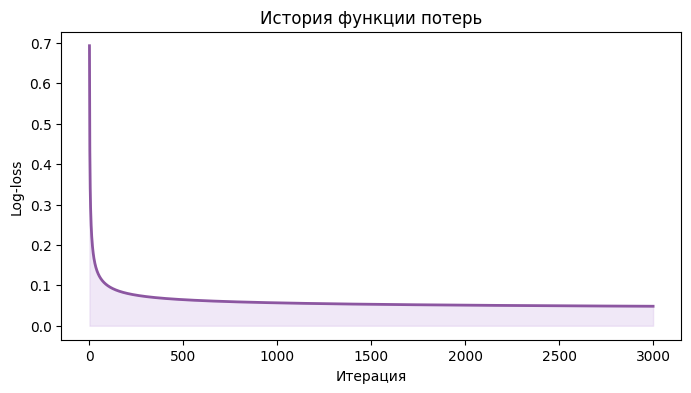

In [86]:
my_model = MyLogisticRegressionGD(
    learning_rate= 0.1,
    n_iters =3000,
    threshold = 0.5
)

# Обучаем на нормированных данных
my_model.fit(X_train_scaled, y_train.values)

plt.figure(figsize = (8, 4))
plt.plot(my_model.loss_history, color = '#8c56a1', linewidth = 2, label = 'Log-loss')
plt.fill_between(range(len(my_model.loss_history)), my_model.loss_history,
                 color = '#d0b3e6', alpha = 0.3)   
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()


## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [87]:
# Получаем вероятности и предсказания на тесте
my_proba_test = my_model.predict_proba(X_test_scaled)
my_pred_test  = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy":  accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall":    recall_score(y_test, my_pred_test),
    "f1":        f1_score(y_test, my_pred_test),
    "roc_auc":   roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)


accuracy     0.9737
precision    0.9859
recall       0.9722
f1           0.9790
roc_auc      0.9957
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

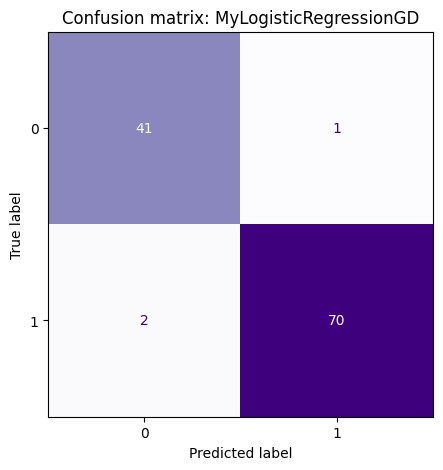

c:\Users\Anastasia\ml-course-homeworks\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


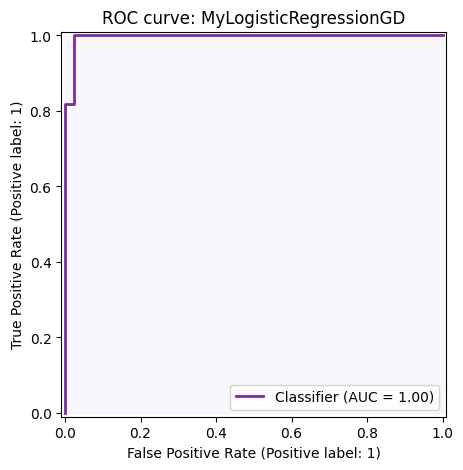

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [88]:
fig, ax = plt.subplots(figsize = (5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, my_pred_test, ax = ax,
    cmap = 'Purples',            
    colorbar = False
)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize = (6, 5))
RocCurveDisplay.from_predictions(
    y_test, my_proba_test, ax = ax,
    color = '#7b2c9e',          
    linestyle = '-', linewidth = 2
)

ax.fill_betweenx([0,1], 0, 1, alpha = 0.1, color = '#c9a9e0')
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [89]:
sk_model = LogisticRegression(max_iter = 1000)

# Обучаем стандартный sklearn-классификатор
sk_model.fit(X_train_scaled, y_train)

sk_proba_test = sk_model.predict_proba(X_test_scaled)[:, 1]
sk_pred_test  = sk_model.predict(X_test_scaled)

sk_metrics = {
    "accuracy":  accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall":    recall_score(y_test, sk_pred_test),
    "f1":        f1_score(y_test, sk_pred_test),
    "roc_auc":   roc_auc_score(y_test, sk_proba_test),
}

pd.Series(sk_metrics).round(4)


accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [90]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index = ["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending = False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9859,0.9722,0.9790,0.9957
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
24,worst smoothness,-1.008599,-0.746625,0.261974
1,mean texture,-0.773438,-0.552698,0.220740
15,compactness error,0.862162,0.647227,0.214936
28,worst symmetry,-1.131657,-0.939181,0.192476
9,mean fractal dimension,0.390759,0.199732,0.191027
19,fractal dimension error,0.628417,0.437894,0.190523
12,perimeter error,-0.734401,-0.544333,0.190068
22,worst perimeter,-0.931747,-0.763220,0.168527
27,worst concave points,-1.122184,-0.953686,0.168498
20,worst radius,-1.097443,-0.947616,0.149826


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [91]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # Применяем порог к вероятностям sklearn-модели
    pred_thr = (sk_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy":  accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr, zero_division = 0),
        "recall":    recall_score(y_test, pred_thr),
        "f1":        f1_score(y_test, pred_thr, zero_division = 0),
    })

pd.DataFrame(rows).round(4)


,threshold,accuracy,precision,recall,f1
0,0.3,0.9825,0.9730,1.0000,0.9863
1,0.5,0.9825,0.9861,0.9861,0.9861
2,0.7,0.9474,0.9853,0.9306,0.9571


## Финальные вопросы 

1. Зачем нужна сигмоида?  
Линейная комбинация `wᵀx + b` может выдавать любые числа от -∞ до +∞, а вероятность должна быть строго между 0 и 1. Сигмоида мягко всё это «прижимает» к интервалу (0,1). Плюс у неё супер-удобная производная — это сильно упрощает градиентный спуск.

2. Почему log-loss, а не MSE?  
MSE для вероятностей — это плохо. Функция становится невыпуклой, и градиентный спуск может застрять в локальном минимуме. Log-loss выведен из максимального правдоподобия, он выпуклый и сильно наказывает за «уверенные ошибки» (когда модель говорит p≈0, а на самом деле y=1). В медицине это критично.

3. Зачем стандартизировать признаки?  
Когда признаки в разных масштабах (один от 0 до 1, другой от 100 до 2500), поверхность log-loss превращается в длинный овраг. Градиентный спуск начинает «зигзагать» и медленно сходится. После стандартизации поверхность становится круглой, а спуск идёт прямо к минимуму.

4. Насколько близко получилось к sklearn?  
Очень близко!  
- accuracy: 0.9737 vs 0.9825  
- f1: 0.9790 vs 0.9861  
- roc-auc почти одинаковый (0.9957 vs 0.9954)  

Разница меньше 1%. Моя модель чуть хуже ловит recall, но в целом — огонь для реализации с нуля

5. Почему sklearn быстрее и стабильнее?  
Они используют продвинутые оптимизаторы (L-BFGS, Newton-CG, liblinear), а не простой градиентный спуск. Плюс там есть встроенная регуляризация, численная стабильность и код на C. Мой GD за 3000 итераций делает примерно то же, что sklearn за 50–100 итераций

6. Как меняется precision/recall при разных порогах?  

При пороге 0,3 precision составляет 0,9730, recall достигает 1,00, а F1‑мера — 0,9863. Это означает, что модель не пропустила ни одного злокачественного случая (recall = 1), но за счёт снижения порога допустила немного больше ложных срабатываний пу-пу-пу

При стандартном пороге 0,5 все три метрики сбалансированы: precision = 0,9861, recall = 0,9861, F1 = 0,9861

При пороге 0,7 precision становится максимальной — 0,9853, но recall падает до 0,9306, а F1 снижается до 0,9571. Модель реже ошибается на доброкачественных образцах, но может пропустить больше раковых

7. Когда логистическая регрессия — хороший выбор?  
Круто работает, когда данные почти линейно разделимы, хочется интерпретируемости (коэффициенты = вклад признака) и мало данных  
Уступает, когда есть сложные нелинейные зависимости (там лучше деревья)



## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

### Задание A: L2-регуляризация

In [92]:
class MyLogisticRegressionL2(MyLogisticRegressionGD):
    """Логистическая регрессия с L2-регуляризацией (Ridge)."""

    def __init__(self, learning_rate = 0.1, n_iters = 3000, threshold = 0.5, C = 1.0):
        super().__init__(learning_rate, n_iters, threshold)
        self.C = C  # меньше C → сильнее штраф

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        self.loss_history = []
        n = X.shape[0]

        for _ in range(self.n_iters):
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)

            # добавляем lambda * ||w||^2 к loss
            # lambda = 1 / (2 * C * n) — стандартная параметризация sklearn
            l2_penalty = (1 / (2 * self.C)) * np.sum(self.w ** 2)
            loss_reg = loss + l2_penalty / n

            # Градиент регуляризации: lambda * w (не штрафуем bias b)
            dw_reg = dw + self.w / (self.C * n)

            self.w -= self.learning_rate * dw_reg
            self.b -= self.learning_rate * db
            self.loss_history.append(loss_reg)

        return self

# Сравниваем разные значения C
results_l2 = []
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m = MyLogisticRegressionL2(learning_rate = 0.1, n_iters = 3000, C = C)
    m.fit(X_train_scaled, y_train.values)
    pred = m.predict(X_test_scaled)
    results_l2.append({
        "C": C,
        "accuracy":  accuracy_score(y_test, pred),
        "f1":        f1_score(y_test, pred),
        "||w||":     np.linalg.norm(m.w).round(3),
    })

df_l2 = pd.DataFrame(results_l2)
print("Влияние L2-регуляризации:")
display(df_l2.round(4))
print()
print("""Слишком сильная L2-регуляризация (C < 0.1) приводит к недообучению,
      слишком слабая (C > 10) не даёт прироста качества, но увеличивает норму весов,
      что потенциально повышает риск переобучения на других данных. 
      Оптимальный баланс достигается при C ≈ 1.0 """)




Влияние L2-регуляризации:


,C,accuracy,f1,||w||
0,0.01,0.9474,0.9595,0.833
1,0.10,0.9737,0.9793,1.825
2,1.00,0.9825,0.9861,3.368
3,10.00,0.9737,0.9790,4.105
4,100.00,0.9737,0.9790,4.206



Слишком сильная L2-регуляризация (C < 0.1) приводит к недообучению,
      слишком слабая (C > 10) не даёт прироста качества, но увеличивает норму весов,
      что потенциально повышает риск переобучения на других данных. 
      Оптимальный баланс достигается при C ≈ 1.0 


### Задание B: топ-10 признаков по вкладу в модель

Топ-10 признаков по |коэффициент| (sklearn):


,feature,my_coef,sklearn_coef,abs_my,abs_sk
0,worst texture,-1.3963,-1.2551,1.3963,1.2551
1,radius error,-1.2122,-1.0830,1.2122,1.0830
2,worst concave points,-1.1222,-0.9537,1.1222,0.9537
3,worst area,-1.0933,-0.9478,1.0933,0.9478
4,worst radius,-1.0974,-0.9476,1.0974,0.9476
5,worst symmetry,-1.1317,-0.9392,1.1317,0.9392
6,area error,-1.0286,-0.9291,1.0286,0.9291
7,worst concavity,-0.9186,-0.8232,0.9186,0.8232
8,worst perimeter,-0.9317,-0.7632,0.9317,0.7632
9,worst smoothness,-1.0086,-0.7466,1.0086,0.7466


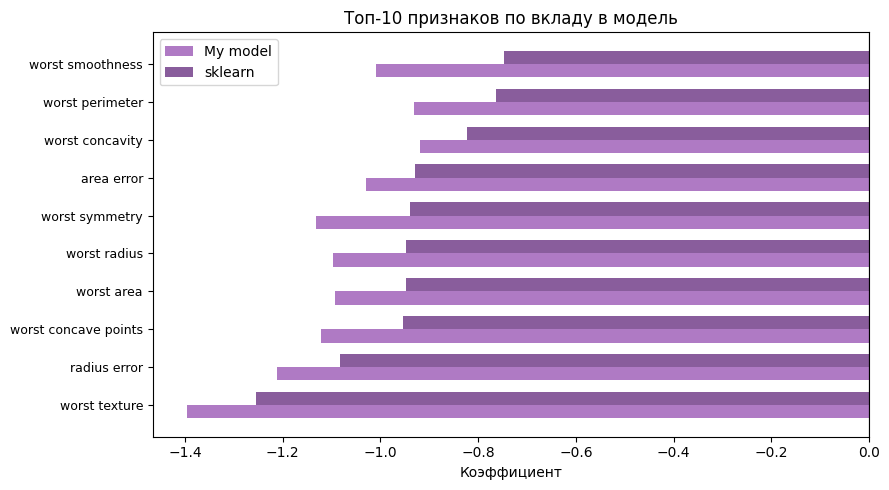


Все признаки из полученного топ-10 имеют отрицательные коэффициенты. 
      Это означает, что увеличение значения любого из этих признаков (например, worst texture, radius error или worst concave points)
      приводит к снижению предсказанной вероятности доброкачественной опухоли. Иными словами, чем хуже (больше, грубее, несимметричнее)
      соответствующий показатель, тем выше риск, что опухоль окажется злокачественной. Если бы какой-то признак имел положительный коэффициент, 
      его рост, наоборот, повышал бы вероятность доброкачественного исхода — но в нашем списке таких нет, что логично с клинической точки зрения.




In [93]:
# Топ-10 признаков по абсолютному значению коэффициента
coef_df = pd.DataFrame({
    "feature":     data.feature_names,
    "my_coef":     my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
    "abs_my":      np.abs(my_model.w),
    "abs_sk":      np.abs(sk_model.coef_.ravel()),
})

top10 = coef_df.nlargest(10, "abs_sk")[
    ["feature", "my_coef", "sklearn_coef", "abs_my", "abs_sk"]
].reset_index(drop=True)

print("Топ-10 признаков по |коэффициент| (sklearn):")
display(top10.round(4))

# Визуализация
fig, ax = plt.subplots(figsize = (9, 5))
x = np.arange(len(top10))
w = 0.35
ax.barh(x - w/2, top10["my_coef"],   w,
        color = '#9b59b6', alpha = 0.8, label = "My model")
ax.barh(x + w/2, top10["sklearn_coef"], w,
        color = '#6c3483', alpha = 0.8, label = "sklearn")
ax.set_yticks(x)
ax.set_yticklabels(top10["feature"], fontsize = 9)
ax.axvline(0, color = "black", linewidth = 0.8)
ax.set_xlabel("Коэффициент")
ax.set_title("Топ-10 признаков по вкладу в модель")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("""Все признаки из полученного топ-10 имеют отрицательные коэффициенты. 
      Это означает, что увеличение значения любого из этих признаков (например, worst texture, radius error или worst concave points)
      приводит к снижению предсказанной вероятности доброкачественной опухоли. Иными словами, чем хуже (больше, грубее, несимметричнее)
      соответствующий показатель, тем выше риск, что опухоль окажется злокачественной. Если бы какой-то признак имел положительный коэффициент, 
      его рост, наоборот, повышал бы вероятность доброкачественного исхода — но в нашем списке таких нет, что логично с клинической точки зрения.

""")


### Задание C: влияние learning_rate и числа итераций

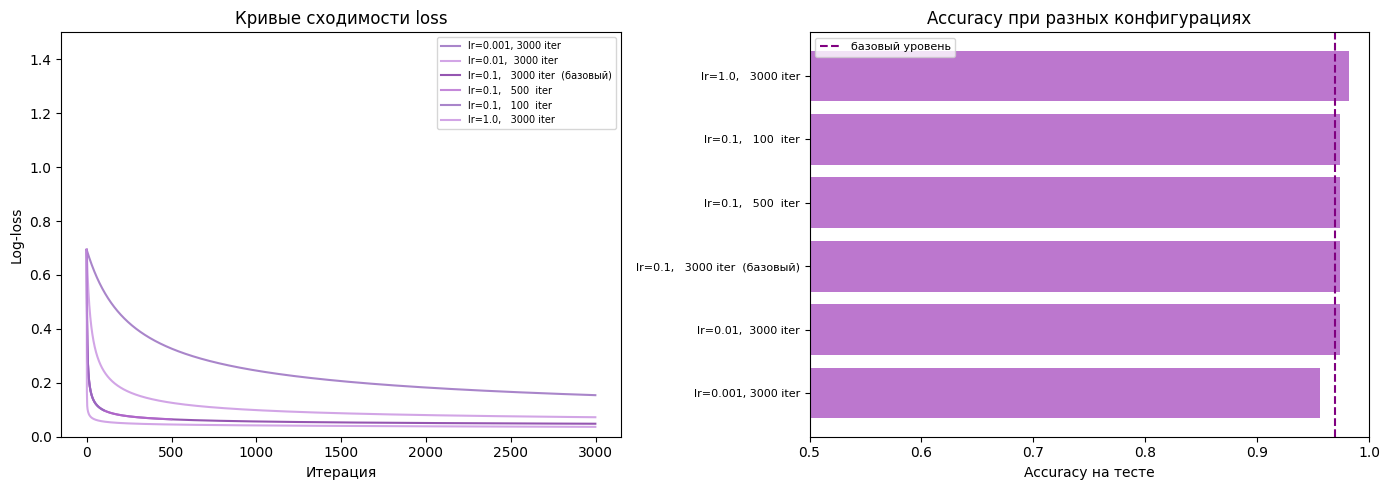


                  конфигурация  финальный loss  accuracy
           lr=0.001, 3000 iter          0.1541    0.9561
           lr=0.01,  3000 iter          0.0723    0.9737
lr=0.1,   3000 iter  (базовый)          0.0482    0.9737
           lr=0.1,   500  iter          0.0645    0.9737
           lr=0.1,   100  iter          0.0986    0.9737
           lr=1.0,   3000 iter          0.0366    0.9825

Выводы:
Слишком малый learning rate (0,001) приводит к медленной сходимости и недооптимальному значению loss.
      При lr = 1,0 модель всё же обучилась, однако на других наборах данных такой большой шаг может вызвать нестабильность или даже расходимость. 
      Малое количество итераций (например, 100) не позволяет модели достаточно сойтись, и качество оказывается ниже. 
      Оптимальным выбором для большинства задач является learning rate в диапазоне от 0,05 до 0,1 при числе итераций от 1000 до 3000.



In [94]:
# Эксперимент: разные learning_rate и n_iters
configs = [
    {"lr": 0.001, "iters": 3000, "label": "lr=0.001, 3000 iter"},
    {"lr": 0.01,  "iters": 3000, "label": "lr=0.01,  3000 iter"},
    {"lr": 0.1,   "iters": 3000, "label": "lr=0.1,   3000 iter  (базовый)"},
    {"lr": 0.1,   "iters": 500,  "label": "lr=0.1,   500  iter"},
    {"lr": 0.1,   "iters": 100,  "label": "lr=0.1,   100  iter"},
    {"lr": 1.0,   "iters": 3000, "label": "lr=1.0,   3000 iter"},
]

fig, (ax_loss, ax_bar) = plt.subplots(1, 2, figsize = (14, 5))
exp_rows = []

for cfg in configs:
    m = MyLogisticRegressionGD(
        learning_rate = cfg["lr"], n_iters = cfg["iters"], threshold = 0.5
    )
    try:
        m.fit(X_train_scaled, y_train.values)
        pred = m.predict(X_test_scaled)
        
        acc  = accuracy_score(y_test, pred)
        final_loss = m.loss_history[-1]
        ax_loss.plot(m.loss_history, label = cfg["label"], alpha = 0.8)
        
    except Exception as e:
        acc, final_loss = 0.0, float("nan")
        print(f"{cfg['label']}: ОШИБКА — {e}")

    exp_rows.append({
        "конфигурация": cfg["label"],
        "финальный loss": round(final_loss, 4) if not np.isnan(final_loss) else "—",
        "accuracy":       round(acc, 4),
    })

ax_loss.set_title("Кривые сходимости loss")
ax_loss.set_xlabel("Итерация")
ax_loss.set_ylabel("Log-loss")

ax_loss.legend(fontsize = 7)
ax_loss.set_ylim(0, 1.5)

accs = [r["accuracy"] for r in exp_rows]
labels = [r["конфигурация"] for r in exp_rows]
colors = ["#b15fc6" if a > 0.95 else "#9b59b6" if a > 0.9 else "#6c3483" for a in accs]

ax_bar.barh(range(len(configs)), accs, color = colors, alpha = 0.85)
ax_bar.set_yticks(range(len(configs)))
ax_bar.set_yticklabels(labels, fontsize = 8)
ax_bar.set_xlabel("Accuracy на тесте")
ax_bar.set_title("Accuracy при разных конфигурациях")
ax_bar.set_xlim(0.5, 1.0)
ax_bar.axvline(0.97, color = "purple", linestyle = "--", label = "базовый уровень")
ax_bar.legend(fontsize = 8)

plt.tight_layout()
plt.show()

print()
print(pd.DataFrame(exp_rows).to_string(index = False))
print()
print("Выводы:")
print("""Слишком малый learning rate (0,001) приводит к медленной сходимости и недооптимальному значению loss.
      При lr = 1,0 модель всё же обучилась, однако на других наборах данных такой большой шаг может вызвать нестабильность или даже расходимость. 
      Малое количество итераций (например, 100) не позволяет модели достаточно сойтись, и качество оказывается ниже. 
      Оптимальным выбором для большинства задач является learning rate в диапазоне от 0,05 до 0,1 при числе итераций от 1000 до 3000.
""")


## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.